In [3]:
pip install scipy

   ---------------------------------------- 0.0/41.0 MB ? eta -:--:--
   -------- ------------------------------- 9.2/41.0 MB 51.8 MB/s eta 0:00:01
   --------------------- ------------------ 22.0/41.0 MB 55.8 MB/s eta 0:00:01
   -------------------------------- ------- 33.3/41.0 MB 55.7 MB/s eta 0:00:01
   ---------------------------------------- 41.0/41.0 MB 51.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: C:\Users\marag\tfvenv\Scripts\python.exe -m pip install --upgrade pip


In [4]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
IMAGE_SIZE = 256
CHANNELS = 3

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10
)

train_generator = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse'
)

Found 1506 images belonging to 3 classes.


In [28]:
train_generator.class_indices

{'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}

In [29]:
class_names = list(train_generator.class_indices.keys())
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [6]:
for image_batch, label_batch in train_generator:
    print(image_batch[0])
    break

[[[0.6857104  0.6857104  0.7327692 ]
  [0.69328713 0.69328713 0.74034595]
  [0.70086396 0.70086396 0.7479228 ]
  ...
  [0.71160495 0.71160495 0.75866383]
  [0.69472855 0.69472855 0.74178743]
  [0.6901961  0.6901961  0.7372549 ]]

 [[0.5776727  0.5776727  0.62473154]
  [0.5783221  0.5783221  0.625381  ]
  [0.57897156 0.57897156 0.6260304 ]
  ...
  [0.71117204 0.71117204 0.75823087]
  [0.6936462  0.6936462  0.7407051 ]
  [0.6901961  0.6901961  0.7372549 ]]

 [[0.5794337  0.5794337  0.6264925 ]
  [0.57683593 0.57683593 0.62389475]
  [0.57423824 0.57423824 0.62129706]
  ...
  [0.7107391  0.7107391  0.7577979 ]
  [0.69256383 0.69256383 0.73962265]
  [0.6901961  0.6901961  0.7372549 ]]

 ...

 [[0.4990837  0.50300527 0.57359356]
  [0.48411387 0.48803544 0.55862373]
  [0.5254902  0.5294118  0.6       ]
  ...
  [0.5466061  0.5495926  0.62708884]
  [0.55093575 0.5534892  0.63055253]
  [0.55526525 0.5573858  0.6340162 ]]

 [[0.49778482 0.50170636 0.5722946 ]
  [0.48671162 0.4906332  0.5612214 ]


In [7]:
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True    
)

validation_generator = validation_datagen.flow_from_directory(
    'dataset/val',
    target_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse'
)

Found 215 images belonging to 3 classes.


In [8]:
test_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True    
)

test_generator = test_datagen.flow_from_directory(
    'dataset/test',
    target_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse'
)

Found 431 images belonging to 3 classes.


In [9]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.Conv2D(32, kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

C:\Users\marag\tfvenv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 12, 12, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 2, 2, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [12]:
1506/32

47.0625

In [13]:
215/32

6.71875

In [14]:
history = model.fit(
    train_generator,
    steps_per_epoch=47,
    batch_size=32,
    validation_data=validation_generator,
    validation_steps=6,
    verbose=1,
    epochs=20,
)

C:\Users\marag\tfvenv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.4815 - loss: 0.9283 - val_accuracy: 0.7083 - val_loss: 0.7563
Epoch 2/20
 1/47 ━━━━━━━━━━━━━━━━━━━━ 35s 777ms/step - accuracy: 0.6875 - loss: 0.7635

C:\Users\marag\tfvenv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.6875 - loss: 0.7635 - val_accuracy: 0.6979 - val_loss: 0.7403
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.6699 - loss: 0.6918 - val_accuracy: 0.8333 - val_loss: 0.4430
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.7812 - loss: 0.4433 - val_accuracy: 0.8333 - val_loss: 0.4150
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.8657 - loss: 0.3343 - val_accuracy: 0.8802 - val_loss: 0.2790
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.8750 - loss: 0.2913 - val_accuracy: 0.8854 - val_loss: 0.3057
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.9067 - loss: 0.2718 - val_accuracy: 0.6667 - val_loss: 0.7202
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.7500 - loss: 0.6036 - val_accuracy: 0.6094 - val_loss: 0.7793
Epoch 9/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.7702 - loss: 0.5419 - val_accuracy: 0.8698 - val_loss: 0.328

In [15]:
scores = model.evaluate(test_generator)

14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9174 - loss: 0.1806


In [16]:
scores

[0.17809976637363434, 0.9280742406845093]

In [17]:
history.params

{'verbose': 1, 'epochs': 20, 'steps': 47}

In [18]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

loss, accuracy, val loss etc are a python list containing values of loss, accuracy etc at the end of each epoch

In [19]:

type(history.history['loss'])

list

In [20]:
len(history.history['loss'])

20

In [21]:
history.history['loss'][:5] # show loss for first 5 epochs

[0.882877767086029,
 0.763496994972229,
 0.603334903717041,
 0.44331100583076477,
 0.3513334393501282]

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [23]:
val_acc

[0.7083333134651184,
 0.6979166865348816,
 0.8333333134651184,
 0.8333333134651184,
 0.8802083134651184,
 0.8854166865348816,
 0.6666666865348816,
 0.609375,
 0.8697916865348816,
 0.8125,
 0.8645833134651184,
 0.8229166865348816,
 0.890625,
 0.9114583134651184,
 0.9010416865348816,
 0.890625,
 0.9114583134651184,
 0.9010416865348816,
 0.9166666865348816,
 0.9114583134651184]

In [24]:
acc

[0.5278154611587524,
 0.6875,
 0.7157394886016846,
 0.78125,
 0.8575305342674255,
 0.875,
 0.8473541140556335,
 0.75,
 0.8018617033958435,
 1.0,
 0.8799185752868652,
 0.84375,
 0.9002713561058044,
 0.90625,
 0.9131614565849304,
 0.875,
 0.9172320365905762,
 0.9375,
 0.9287652373313904,
 1.0]

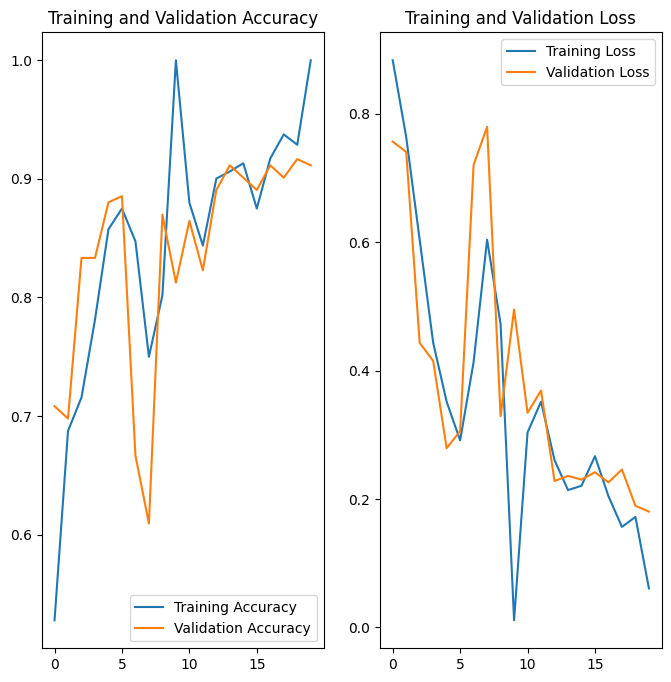

In [25]:
EPOCHS = 20

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Run prediction on a sample image

first image to predict
actual label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 636ms/step
predicted label: Potato___Late_blight


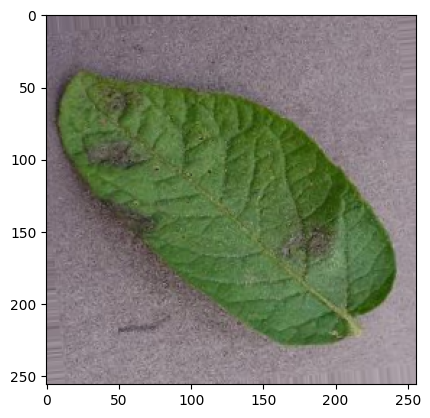

In [31]:
import numpy as np


for image_batch, label_batch in test_generator:
    first_image = image_batch[0]
    first_label = int(label_batch[0])
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(image_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])
    
    break

Write a function for inference

In [32]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i])
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

Now run inference on few sample images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


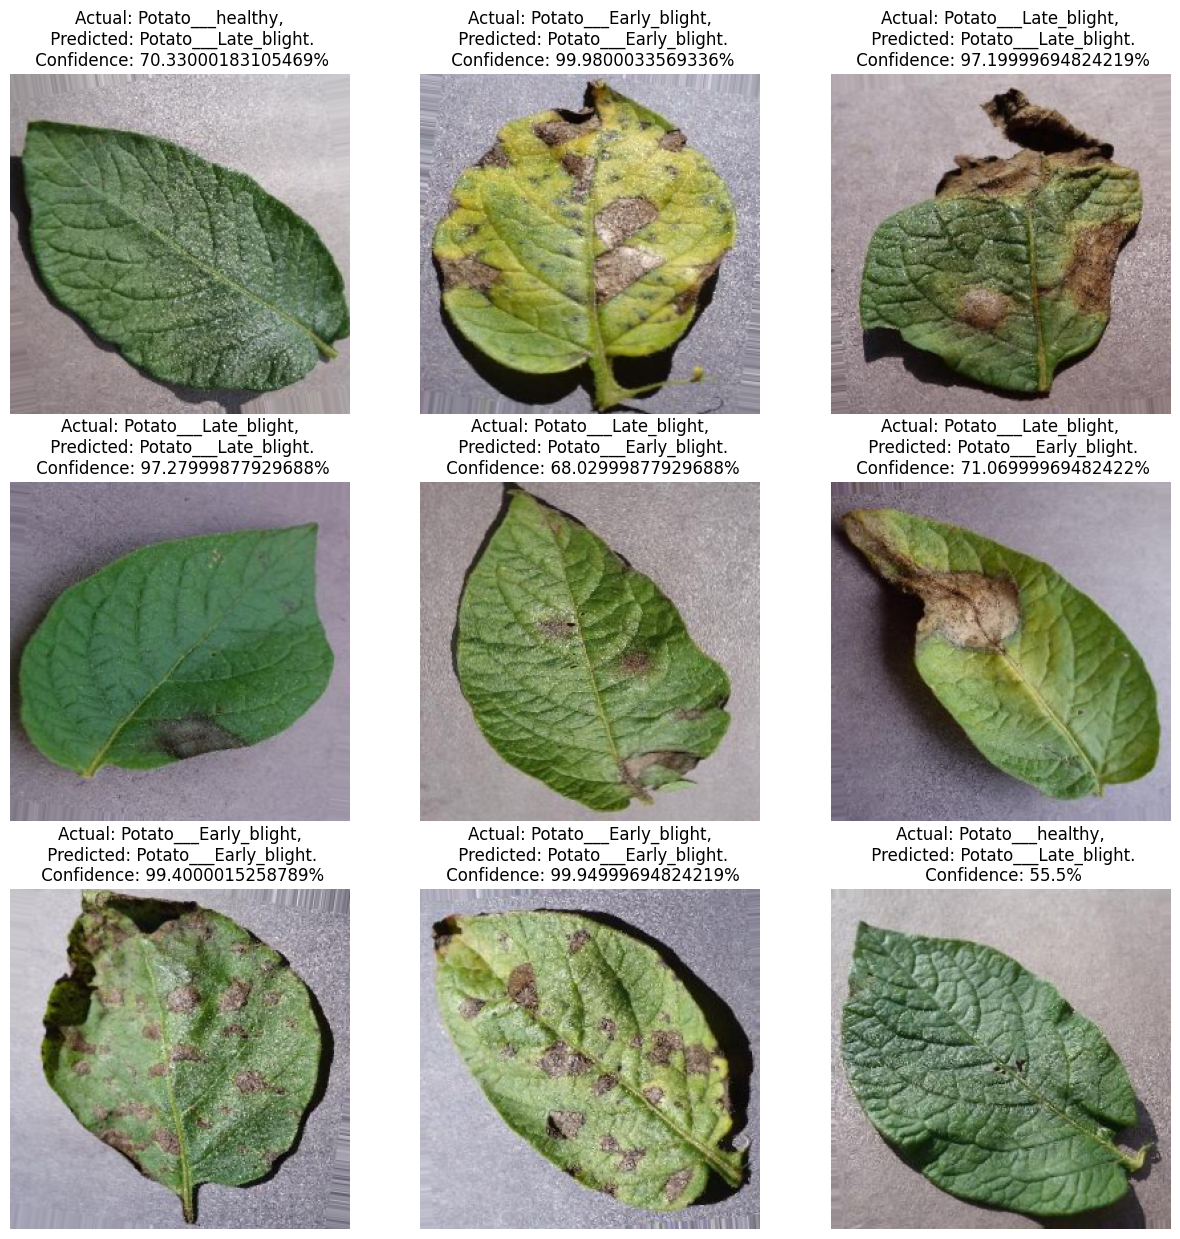

In [34]:
plt.figure(figsize=(15, 15))
for images, labels in test_generator:
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        
        predicted_class, confidence = predict(model, images[i])
        actual_class = class_names[int(labels[i])] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")
    break

Saving the Model
Save model in h5 format so that there is just one file and we can upload that to GCP conveniently

In [35]:
model.save("../potatoes.h5")